<a href="https://colab.research.google.com/github/NaveenS-cool/UHIA-of-Thrissur/blob/main/UHIA_of_thrissur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
!git clone https://github.com/NaveenS-cool/UHIA-of-Thrissur.git  #For the raster and shapefiles

fatal: destination path 'UHIA-of-Thrissur' already exists and is not an empty directory.


In [33]:
!pip install rasterio geopandas matplotlib seaborn scipy -q  #installing libraries

In [34]:
#importing the libraries

import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [35]:
uhi_raster = rasterio.open("/content/UHIA-of-Thrissur/raster_files/thrissur_city_uhi.tif")
lulc_raster = rasterio.open("/content/UHIA-of-Thrissur/raster_files/thrissur_city_lulc.tif")

boundary = gpd.read_file("/content/UHIA-of-Thrissur/shapefile/Thrissur__city.shp")

In [36]:
LST  = uhi_raster.read(1).astype(float)
NDVI = uhi_raster.read(2).astype(float)
NDBI = uhi_raster.read(3).astype(float)
profile = uhi_raster.profile
transform = uhi_raster.transform

LULC = lulc_raster.read(1).astype(float)

In [37]:
print(f'LST  → Min: {np.nanmin(LST):.2f}  Max: {np.nanmax(LST):.2f}  Mean: {np.nanmean(LST):.2f}')
print(f'NDVI → Min: {np.nanmin(NDVI):.2f}  Max: {np.nanmax(NDVI):.2f}  Mean: {np.nanmean(NDVI):.2f}')
print(f'NDBI → Min: {np.nanmin(NDBI):.2f}  Max: {np.nanmax(NDBI):.2f}  Mean: {np.nanmean(NDBI):.2f}')

LST  → Min: 28.90  Max: 45.00  Mean: 36.51
NDVI → Min: -0.02  Max: 0.55  Mean: 0.27
NDBI → Min: -0.31  Max: 0.20  Mean: -0.09


In [38]:
def mask_array(arr, min_val, max_val):
    arr = np.where((arr < min_val) | (arr > max_val), np.nan, arr)
    return arr

LST  = mask_array(LST,  25, 50)    # Valid LST range for Thrissur
NDVI = mask_array(NDVI, -1, 1)    # Valid NDVI range
NDBI = mask_array(NDBI, -1, 1)    # Valid NDBI range
LULC = mask_array(LULC, 0, 100)   # Valid LULC class range

print('Masking done')
print(f'LST  → Min: {np.nanmin(LST):.2f}  Max: {np.nanmax(LST):.2f}  Mean: {np.nanmean(LST):.2f}')
print(f'NDVI → Min: {np.nanmin(NDVI):.2f}  Max: {np.nanmax(NDVI):.2f}  Mean: {np.nanmean(NDVI):.2f}')
print(f'NDBI → Min: {np.nanmin(NDBI):.2f}  Max: {np.nanmax(NDBI):.2f}  Mean: {np.nanmean(NDBI):.2f}')

Masking done
LST  → Min: 28.90  Max: 45.00  Mean: 36.51
NDVI → Min: -0.02  Max: 0.55  Mean: 0.27
NDBI → Min: -0.31  Max: 0.20  Mean: -0.09


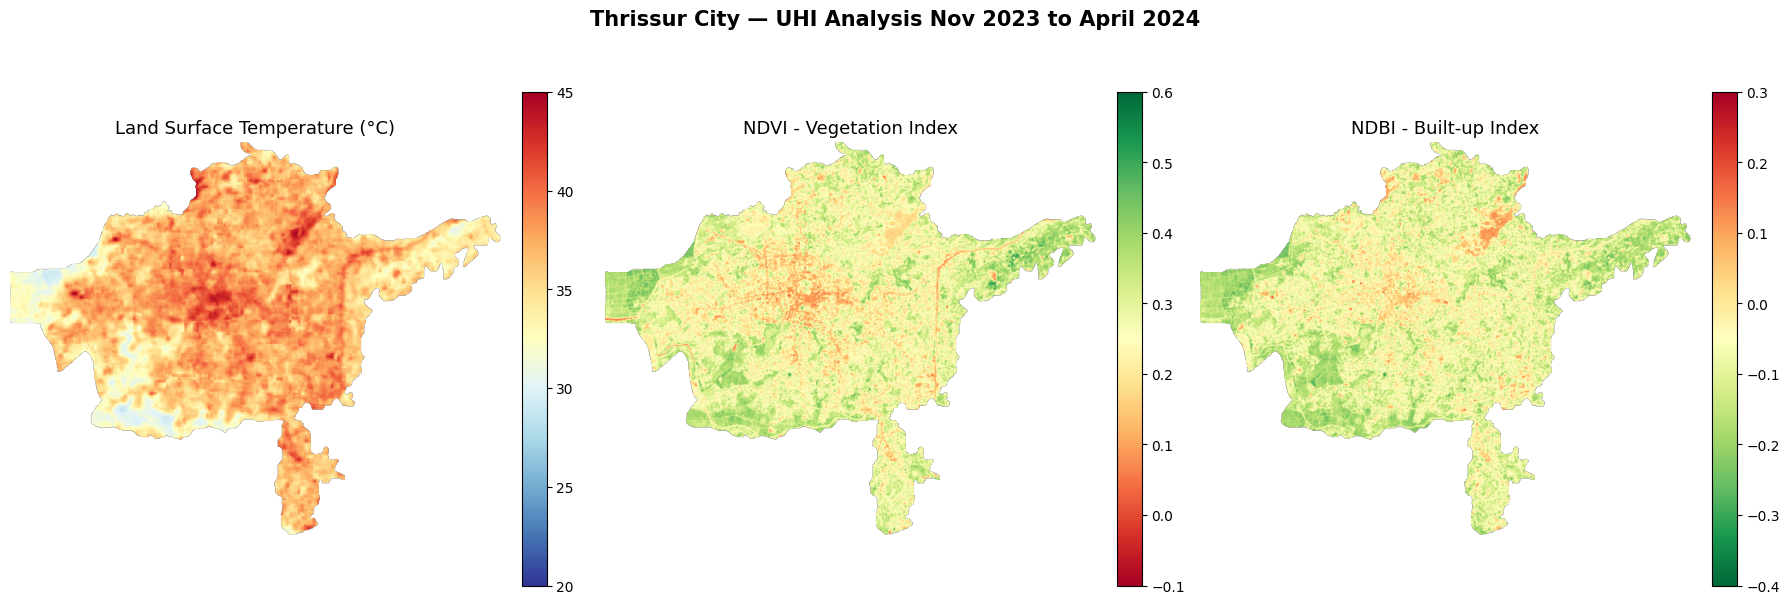

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# LST map
im1 = axes[0].imshow(LST, cmap='RdYlBu_r', vmin=20, vmax=45)
axes[0].set_title('Land Surface Temperature (°C)', fontsize=13)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# NDVI map
im2 = axes[1].imshow(NDVI, cmap='RdYlGn', vmin=-0.1, vmax=0.6)
axes[1].set_title('NDVI - Vegetation Index', fontsize=13)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# NDBI map
im3 = axes[2].imshow(NDBI, cmap='RdYlGn_r', vmin=-0.4, vmax=0.3)
axes[2].set_title('NDBI - Built-up Index', fontsize=13)
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle('Thrissur City — UHI Analysis Nov 2023 to April 2024', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Thrissur_indices.png', dpi=150, bbox_inches='tight')
plt.show()


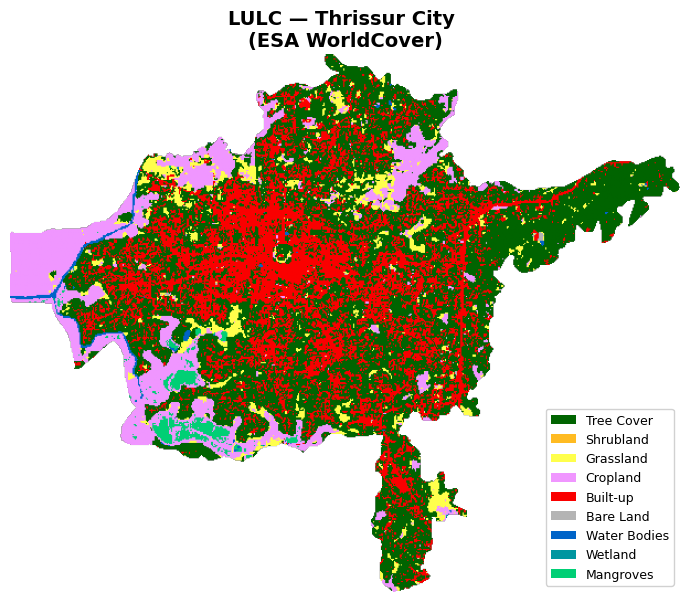

In [40]:
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

lulc_classes = {
    10: 'Tree Cover',
    20: 'Shrubland',
    30: 'Grassland',
    40: 'Cropland',
    50: 'Built-up',
    60: 'Bare Land',
    80: 'Water Bodies',
    90: 'Wetland',
    95: 'Mangroves'
}
lulc_colors = {
    10: '#006400',   # Dark green - Forest
    20: '#ffbb22',   # Yellow - Shrubland
    30: '#ffff4c',   # Light yellow - Grassland
    40: '#f096ff',   # Pink - Cropland
    50: '#fa0000',   # Red - Built-up
    60: '#b4b4b4',   # Gray - Bare land
    80: '#0064c8',   # Blue - Water
    90: '#0096a0',   # Teal - Wetland
    95: '#00cf75'    # Light green - Mangroves
}

#colormap
unique_classes = sorted(lulc_classes.keys())
color_list = [lulc_colors[c] for c in unique_classes]
cmap = mcolors.ListedColormap(color_list)
bounds = [c - 5 for c in unique_classes] + [unique_classes[-1] + 5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(LULC, cmap=cmap, norm=norm)
ax.set_title('LULC — Thrissur City \n(ESA WorldCover)',
             fontsize=14, fontweight='bold')
ax.axis('off')

#
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=lulc_colors[c], label=lulc_classes[c])
                   for c in unique_classes]
ax.legend(handles=legend_elements, loc='lower right',
          fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('Thrissur_LULC.png', dpi=150, bbox_inches='tight')
plt.show()


In [41]:
import pandas as pd

In [42]:
#Dataframe
df = pd.DataFrame({'LST': LST.flatten(),'NDVI': NDVI.flatten(),
                   'NDBI': NDBI.flatten()}).dropna()
# Correlation
corr = df.corr()
print(corr)

           LST      NDVI      NDBI
LST   1.000000 -0.689482  0.707766
NDVI -0.689482  1.000000 -0.874977
NDBI  0.707766 -0.874977  1.000000


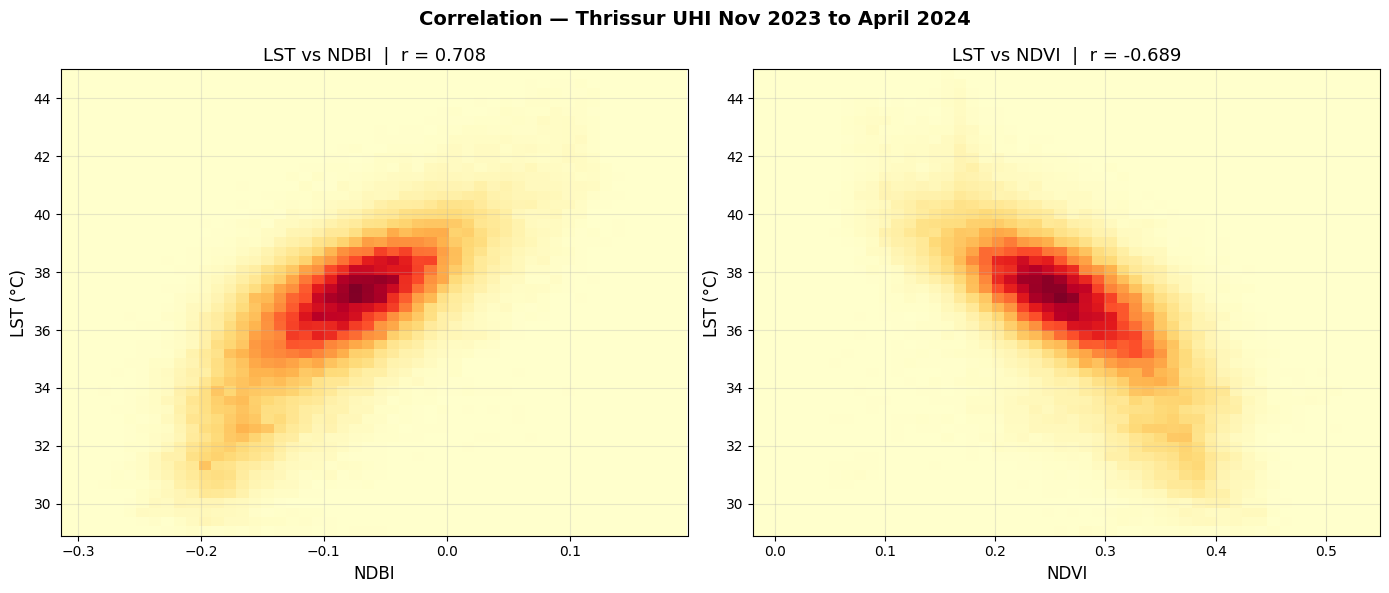

In [43]:
#2D Histograms of LSt vs NDVI and LST vs NDBI
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col in zip(axes, ['NDBI', 'NDVI']):
    r = corr.loc['LST', col]
    ax.hist2d(df[col], df['LST'], bins=50, cmap='YlOrRd')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('LST (°C)', fontsize=12)
    ax.set_title(f'LST vs {col}  |  r = {r:.3f}', fontsize=13)
    ax.grid(alpha=0.3)

plt.suptitle('Correlation — Thrissur UHI Nov 2023 to April 2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Thrissur_Correlation.png', dpi=150, bbox_inches='tight')
plt.show()

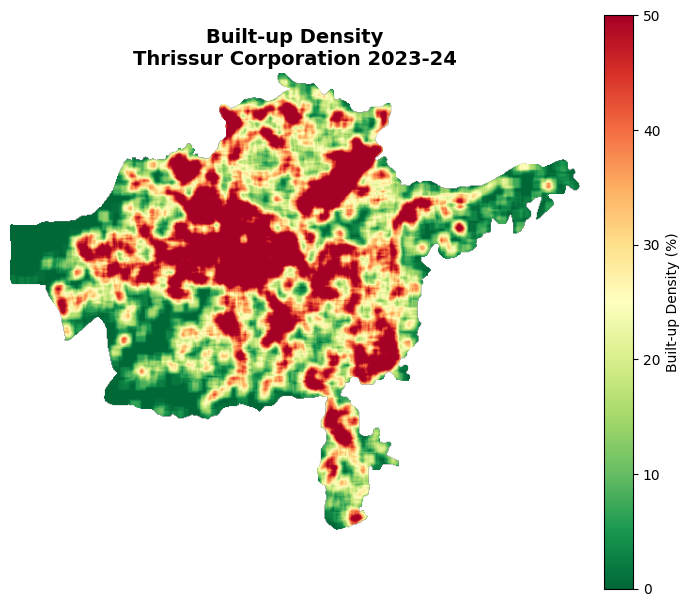

Mean built-up density → 28.3%
Max built-up density  → 100.0%


In [44]:
from scipy.ndimage import uniform_filter

from scipy.ndimage import uniform_filter

# Reduce window from 33 to 11 pixels (~330m instead of 1km)
buildup_density = uniform_filter((NDBI > -0.05).astype(float), size=11) * 100
buildup_density = np.where(np.isnan(NDBI), np.nan, buildup_density)

# Plot
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(buildup_density, cmap='RdYlGn_r', vmin=0, vmax=50)
ax.set_title('Built-up Density\nThrissur Corporation 2023-24',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Built-up Density (%)')
plt.tight_layout()
plt.savefig('ThrissurCorp_Buildup.png', dpi=150, bbox_inches='tight')
plt.show()
# Stats
print(f'Mean built-up density → {np.nanmean(buildup_density):.1f}%')
print(f'Max built-up density  → {np.nanmax(buildup_density):.1f}%')

LST vs Built-up Density → r = 0.790


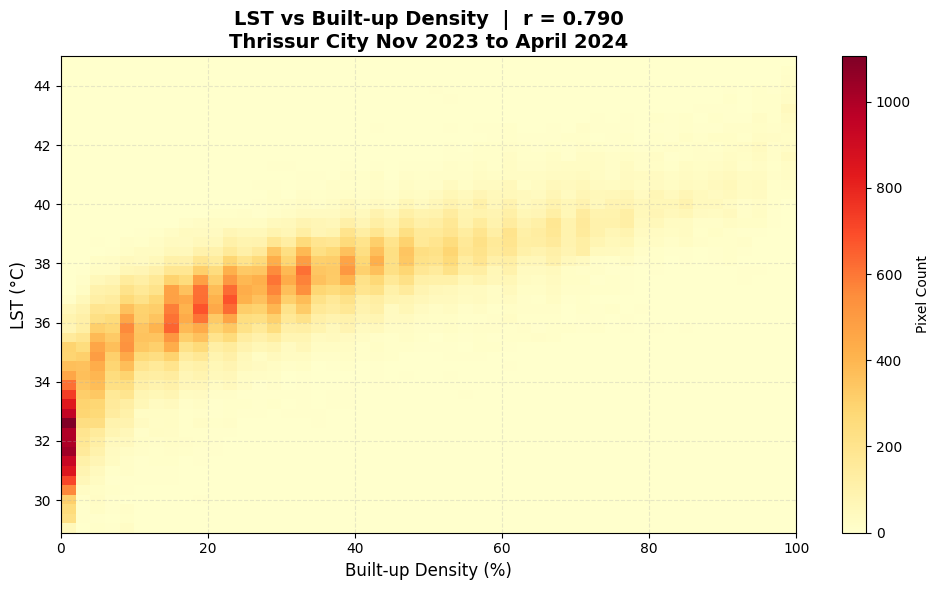

In [45]:
# Flatten and combine
df_buildup = pd.DataFrame({
    'LST'           : LST.flatten(),
    'Buildup_Density': buildup_density.flatten()
}).dropna()

# Correlation
r = df_buildup.corr().loc['LST', 'Buildup_Density']
print(f'LST vs Built-up Density → r = {r:.3f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist2d(df_buildup['Buildup_Density'], df_buildup['LST'],
          bins=50, cmap='YlOrRd')
plt.colorbar(ax.collections[0] if hasattr(ax, 'collections')
             else plt.cm.ScalarMappable(cmap='YlOrRd'),
             ax=ax, label='Pixel Count')

ax.set_xlabel('Built-up Density (%)', fontsize=12)
ax.set_ylabel('LST (°C)', fontsize=12)
ax.set_title(f'LST vs Built-up Density  |  r = {r:.3f}\nThrissur City Nov 2023 to April 2024',
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Thrissur_LST_Buildup.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
def normalize(arr):
    return (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr))

LST_norm     = normalize(LST)
Buildup_norm = normalize(buildup_density)

# Combined UHI Index (60% LST + 40% Built-up)
UHI_index = (0.6 * LST_norm) + (0.4 * Buildup_norm)

# Stats
m, s = np.nanmean(UHI_index), np.nanstd(UHI_index)
print(f'Mean index: {m:.2f}  Std index: {s:.2f}')

Mean index: 0.40  Std index: 0.17


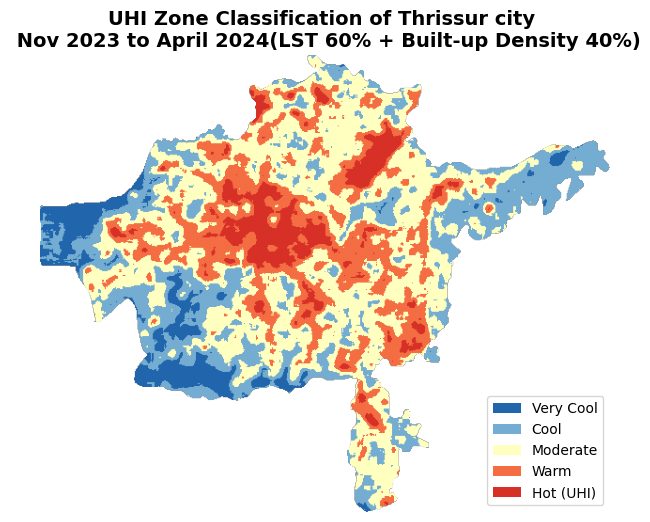

Very Cool       → 7.2%
Cool            → 23.9%
Moderate        → 39.6%
Warm            → 21.7%
Hot (UHI)       → 7.6%


In [47]:


# Zone config
zones  = ['Very Cool','Cool','Moderate','Warm','Hot (UHI)']
colors = ['#2166ac','#74add1','#ffffbf','#f46d43','#d73027']
cuts   = [m + i*s for i in [-1.5, -0.5, 0.5, 1.5]]

# Classify
UHI_zones = np.digitize(UHI_index, cuts) + 1
UHI_zones = np.where(np.isnan(UHI_index), np.nan, UHI_zones)

# Plot
fig, ax = plt.subplots(figsize=(6,6))
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([0.5,1.5,2.5,3.5,4.5,5.5], cmap.N)
ax.imshow(UHI_zones, cmap=cmap, norm=norm)
ax.set_title('UHI Zone Classification of Thrissur city \n Nov 2023 to April 2024(LST 60% + Built-up Density 40%)', fontsize=14, fontweight='bold')
ax.axis('off')
ax.legend(handles=[Patch(facecolor=c, label=l) for c,l in zip(colors,zones)],
          loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('Thrissur_UHI_Zones.png', dpi=150, bbox_inches='tight')
plt.show()

# Zone stats
total = np.sum(~np.isnan(UHI_zones))
for i,z in enumerate(zones):
    pct = np.sum(UHI_zones == i+1) / total * 100
    print(f'{z:15s} → {pct:.1f}%')